In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt
from corner import corner

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Setting Networks

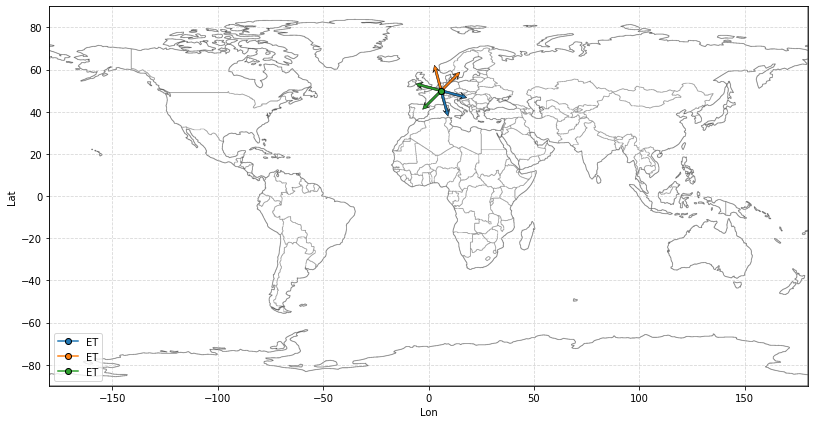

In [2]:
det_ET1 = {'name':'ET','lon':6, 'lat':50, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':6, 'lat':50, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':6, 'lat':50, 'rot':-120, 'shape':60}
detectors = [det_ET1, det_ET2, det_ET3]

fig = gw.draw_detectors(detectors)

### Setting GW Source Propertites

In [3]:
GwPrms = {}                                                                                                
GwPrms['dL'] 	= 10.96
GwPrms['Mc'] 	= 9.57
GwPrms['eta'] 	= 0.25
GwPrms['iota'] 	= 0.52
GwPrms['psi'] 	= 2.32
GwPrms['t_coal'] 	= 0.00
GwPrms['phi_coal'] 	= -1.37
GwPrms['RA'] 	= -135.75
GwPrms['Dec'] 	= 72.92
GwPrms['sz1'] 	= 0.31
GwPrms['sz2'] 	= 0.16

GwPrms['sx1'] 	= 0.00
GwPrms['sy1'] 	= 0.00

GwPrms['sx2'] 	= 0.00
GwPrms['sy2'] 	= 0.00

### Loading Precomputed DALI Tensors

In [4]:
tensors = np.load("DaliTensors.npz")

Fisher = tensors["Fisher"]
Db12   = tensors["Db12"]
Db22   = tensors["Db22"]
Tp13   = tensors["Tp13"]
Tp23   = tensors["Tp23"]
Tp33   = tensors["Tp33"]

Doublet = [Db12, Db22]
Triplet = [Tp13, Tp23, Tp33]

dali_tensors = [Fisher, Doublet, Triplet]

### Running GWDALI (Doublet)
- Doublet-DALI With Tensors Pre-Computed

In [5]:
res_Db = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"], # Free Parameters
					approx = "TaylorF2",
					method="Doublet",
					sampler="nestle",
					new_priors = None,
					dali_tensors = dali_tensors,
					plot_signal=False,
					nlive = 300, # nlive for nested sampling
                    # nsteps = None, # used in emcee/ptemcee
					# nwalkers = None, # used in emcee/ptemcee
					# ntemps = None, # used in ptemcee
                    # nsamples = None, # used in ptemcee
					# npool = 1, Number of cores for bilby paralelization
					remove_out=True, # Remove output path
					verbose = True,
					hide_info = False, # Hide GWDALI informatins
					output_name=f'gwdali_output/'
				)

print("GWDALI (Doublet) concluded!")

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Doublet
 Approx:  TaylorF2 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.981907492411947
ET (2) SNR = 12.676552183767917
ET (3) SNR = 11.52371525738471
Computing Tensors ...

<< DALI tensors loaded by the user >>

tensors loaded successfully!

>> DALI-Tensors OK!


 Running Sampler (nestle)...

it=  1425 logz=-4.31440558900
GWDALI (Doublet) concluded!


### Running GWDALI (Exact)

In [6]:
res_Ex = gw.GWDALI(	GwPrms=GwPrms,
					detectors=detectors,
					FreeParams=["dL","iota"], # Free Parameters
					approx = "TaylorF2",
					method = "Exact",
					sampler="nestle",
					new_priors = None,
					plot_signal=False,
					nlive = 300, # nlive in nested sampling
                    # nsteps = None, # used in emcee / ptemcee
					# nwalkers = None, # used in emcee / ptemcee
					# ntemps = None, # used in ptemcee
                    # nsamples = 6000, # used in ptemcee
                    # npool = 1,
					remove_out=True, # Remove output path
					verbose = True,
					hide_info = False, # Hide GWDALI informatins
					output_name=f'gwdali_output/'
				)

print("GWDALI (Exact) concluded!")

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['dL', 'iota']
 Method:  Exact
 Approx:  TaylorF2 

>> Injections:
	 dL: 10.96
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.981907492411947
ET (2) SNR = 12.676552183767917
ET (3) SNR = 11.52371525738471
Computing Tensors ...

>> DALI-Tensors OK!


 Running Sampler (nestle)...

it=  1559 logz=-4.765466526
GWDALI (Exact) concluded!


### Reading Results

In [7]:
Results, Tensors, Time = res_Db

time_dali, time_mcmc = Time

samples_Db, priors, likelihood_times_Db, Evidence = Results

logZ, logZ_err = Evidence # Valid only for Nested Sampling

print(f"log(Evidence) = {logZ:.2f} +- {logZ_err:.2f}")

log(Evidence) = -3.85 +- 0.10


In [8]:
samples_Ex = res_Ex[0][0]
likelihood_times_Ex = res_Ex[0][2]

### Plotting Results with "getdist"

Removed no burn in
Removed no burn in


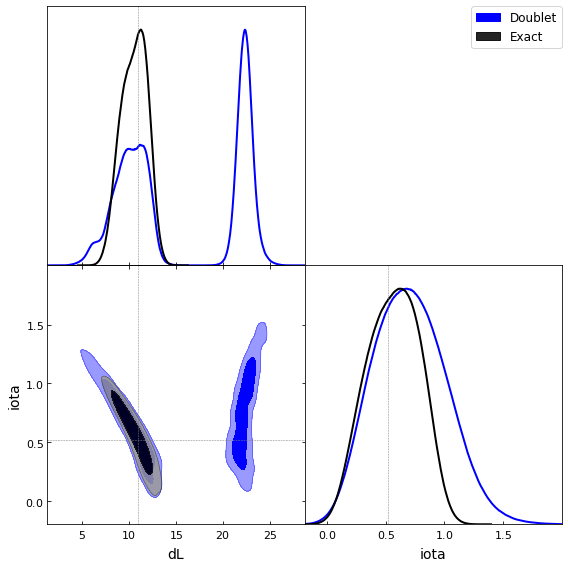

In [9]:
from getdist import MCSamples, plots

FreeParams = ["dL","iota"]

samples1 = MCSamples(samples=samples_Db, label="Doublet", names=FreeParams)
samples2 = MCSamples(samples=samples_Ex, label="Exact", names=FreeParams)

g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samples1, samples2], 
                filled=True,
                markers = {"dL":GwPrms["dL"],
                           "iota":GwPrms["iota"]},
                colors=["b","k"],
                line_args=[ {"color":"b","lw":2},
                            {"color":"k","lw":2}] 
                )


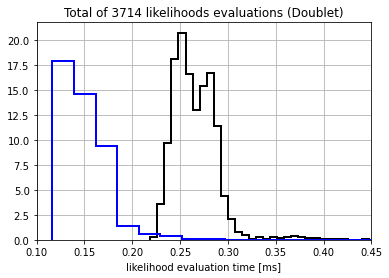

In [10]:
# The first likelihood evaluation is every the slower
plt.hist(np.sort(likelihood_times_Ex)[:-2]/1.e-2,bins=60,color='k',lw=2,histtype='step',density=True)
plt.hist(likelihood_times_Db[1:]/1.e-2,bins=60,color='b',lw=2,histtype='step',density=True)
plt.xlabel('likelihood evaluation time [ms]')
plt.title(f"Total of {len(likelihood_times_Db)} likelihoods evaluations (Doublet)")
plt.xlim(0.1,0.45)
plt.grid()
plt.show()

## Solving Problem of Bimodality in $d_L$ for Doublet
* $d_L\rightarrow 1/d_L$

In [11]:
GwPrms2 = {}
for key in GwPrms.keys():
    if key!="dL": 
        GwPrms2[key] = GwPrms[key]
    else:
        GwPrms2["inv_dL"] = 1./GwPrms["dL"]

res_Db_v2 = gw.GWDALI(	GwPrms=GwPrms2,
                        detectors=detectors,
                        FreeParams=["inv_dL","iota"], # Free Parameters
                        approx = "TaylorF2",
                        method = "Doublet",
                        sampler="nestle",
                        new_priors = None,
                        # dali_tensors = dali_tensors, # Not used for Exact Likelihoods
                        diff_method = "numdiff",
                        plot_signal=False,
                        nlive = 300, # nlive for nested sampling
                        # nsteps = None,
                        # nwalkers = None,
                        # ntemps = None,
                        remove_out=True, # Remove output path
                        verbose = True,
                        hide_info = False, # Hide GWDALI informatins
                        output_name=f'gwdali_output/'
                    )

print("GWDALI (Doublet: 1/dL) concluded!")

#==============================
... Running GWDALI_v1 ...
#============================== 


 Free Parameters:  ['inv_dL', 'iota']
 Method:  Doublet
 Approx:  TaylorF2 

>> Injections:
	 inv_dL: 0.09
	 Mc: 9.57
	 eta: 0.25
	 iota: 0.52
	 psi: 2.32
	 t_coal: 0.00
	 phi_coal: -1.37
	 RA: -135.75
	 Dec: 72.92
	 sz1: 0.31
	 sz2: 0.16
	 sx1: 0.00
	 sy1: 0.00
	 sx2: 0.00
	 sy2: 0.00


ET (1) SNR = 12.981907492411947
ET (2) SNR = 12.676552183767917
ET (3) SNR = 11.52371525738471
Computing Tensors ...
Loading JAX derivatives ...

*********************************** [1] Detector: ET ***********************************


==================================== Computing DALI Tensors (Doublet) ====================================



 # Computing First-Order Derivatives (diff_method = numdiff) .....

	 (inv_dL)	 [1-2]	 Diff[inv_dL] OK! 	(0 seconds)
	 (iota)	 [2-2]	 Diff[iota] OK! 	(0 seconds)

>> First Derivatives Concluded in 0min:0sec!



	Fisher(1|1) [1,1] ..............................

Computing

### Comparing Exact x Doublet ($d_L$) x Doublet ($d_L^{-1}$)

In [12]:
samples_Db_v2 = res_Db_v2[0][0]
likelihood_times_Db_v2 = res_Db_v2[0][2]

invDL, Iota = samples_Db_v2.T
samples_Db2 = np.transpose([1./invDL, Iota])

Removed no burn in
Removed no burn in
Removed no burn in


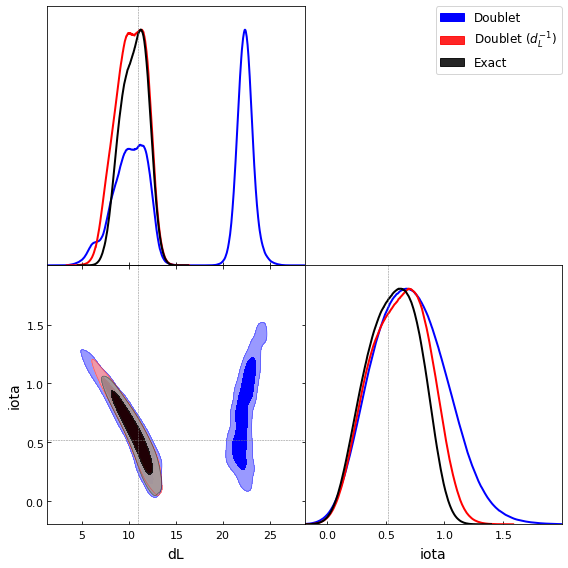

In [13]:
samples1 = MCSamples(samples=samples_Db, label="Doublet", names=FreeParams)
samples2 = MCSamples(samples=samples_Db2, label="Doublet ($d_L^{-1}$)", names=FreeParams)
samples3 = MCSamples(samples=samples_Ex, label="Exact", names=FreeParams)

g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samples1, samples2,samples3], 
                filled=True,
                markers = {"dL":GwPrms["dL"],
                           "iota":GwPrms["iota"]},
                colors=["b","r","k"],
                line_args=[ {"color":"b","lw":2},
                            {"color":"r","lw":2},
                            {"color":"k","lw":2}] 
                )


